<a href="https://colab.research.google.com/github/hamidb201214-svg/Lectures/blob/main/M1_CaseStudy_Nomad_Cities_SOLUTIONS_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case study: types of digital nomad city

780 cities, 20+ columns describing what each one costs and what it is like to live in.
Lecture 1 reduced those columns to a few factors. Now we ask the next question:

> **How many types of city are there, and which city is which?**

We answer it with **PCA + K-means**, and we make both size choices properly:

1. **How many components?** — a scree (elbow) plot and a cumulative variance plot
2. **How many clusters?** — an inertia elbow and a silhouette score
3. **What are they?** — name the types and find something worth presenting

**Exercises 1 to 5.** Solutions are in the cells marked *Solution*.

## 0. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
URL    = 'https://sds-aau.github.io/SDS-master/M1/data/cities.csv'
MIRROR = 'https://raw.githubusercontent.com/SDS-aau/SDS-master/master/M1/data/cities.csv'

try:
    cities = pd.read_csv(URL)
except Exception:
    cities = pd.read_csv(MIRROR)      # in case the course site is blocked

print(cities.shape)
cities.head()

(780, 25)


,place,alpha-2,region,sub-region,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,...,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,Budapest,HU,Europe,Eastern Europe,1364.0,152.41,1273.0,1.73,1.73,1.0,...,52.7,28.17,1.0,0.27,0.6,0.40,0.80,0.86,1.00,0.0
1,Chiang Mai,TH,Asia,South-eastern Asia,777.0,98.88,780.0,0.85,0.85,0.8,...,78.8,44.53,0.8,0.60,0.6,0.40,0.62,0.75,0.40,0.0
2,Phuket,TH,Asia,South-eastern Asia,1012.0,155.43,1714.0,1.41,1.41,0.8,...,78.8,44.53,0.6,0.80,0.6,0.42,0.60,0.75,0.82,0.0
3,Bangkok,TH,Asia,South-eastern Asia,1197.0,131.41,1158.0,2.12,2.12,1.0,...,78.8,44.53,0.8,0.80,1.0,0.42,0.82,0.72,1.00,0.0
4,Ko Samui,TH,Asia,South-eastern Asia,1352.0,169.56,1347.0,1.41,1.41,0.8,...,78.8,44.53,0.8,0.80,1.0,0.40,0.80,0.80,0.80,0.0


### Two small fixes first

Three columns would quietly break the analysis:

* `racism` is a 0–1 score, but one city has the value `1.8e+28` — a typo in the source data
* `cost_beer` is an exact copy of `coffee_in_cafe`, so drink prices would count twice
* `weed` is the same value for 88% of cities, so it cannot separate anything

In [ ]:
cities.loc[cities.racism > 1, 'racism'] = cities.racism.median()   # fix the typo
numeric = cities.select_dtypes('number').drop(columns=['cost_beer', 'weed'])

print(numeric.shape[1], 'columns used')

19 columns used


---
## 1. Scale, then choose how many components

Scaling first, because the columns are in different units — dollars, Mbps, and scores
between 0 and 1. Without it `cost_nomad` would decide everything on its own.

Then PCA. Many of these columns measure the same underlying thing: four are about cost,
three are about safety and freedom. Distance counts each column separately, so whichever
idea has the most columns quietly gets the most weight. PCA removes that double-counting.

But how many components should we keep?

In [ ]:
X = StandardScaler().fit_transform(numeric)

pca_full = PCA().fit(X)                       # fit ALL components first, to inspect them
variance = pca_full.explained_variance_ratio_
cumulative = variance.cumsum()

pd.DataFrame({
    'component': range(1, len(variance) + 1),
    'variance': variance.round(3),
    'cumulative': cumulative.round(3),
    'eigenvalue': pca_full.explained_variance_.round(2),
}).head(10)

,component,variance,cumulative,eigenvalue
0,1,0.426,0.426,8.10
1,2,0.093,0.519,1.78
2,3,0.069,0.588,1.30
3,4,0.049,0.637,0.93
4,5,0.047,0.684,0.89
5,6,0.040,0.724,0.76
6,7,0.037,0.761,0.71
7,8,0.033,0.794,0.63
8,9,0.031,0.825,0.60
9,10,0.028,0.853,0.53


### The two plots

**Left — the scree plot (the elbow).** How much each component adds on its own. Look for
the bend, where components stop being worth keeping.

**Right — cumulative variance.** How much of the original information you still have.
A common rule is to keep enough components to reach 80%.

These two rules often disagree, and you have to decide.

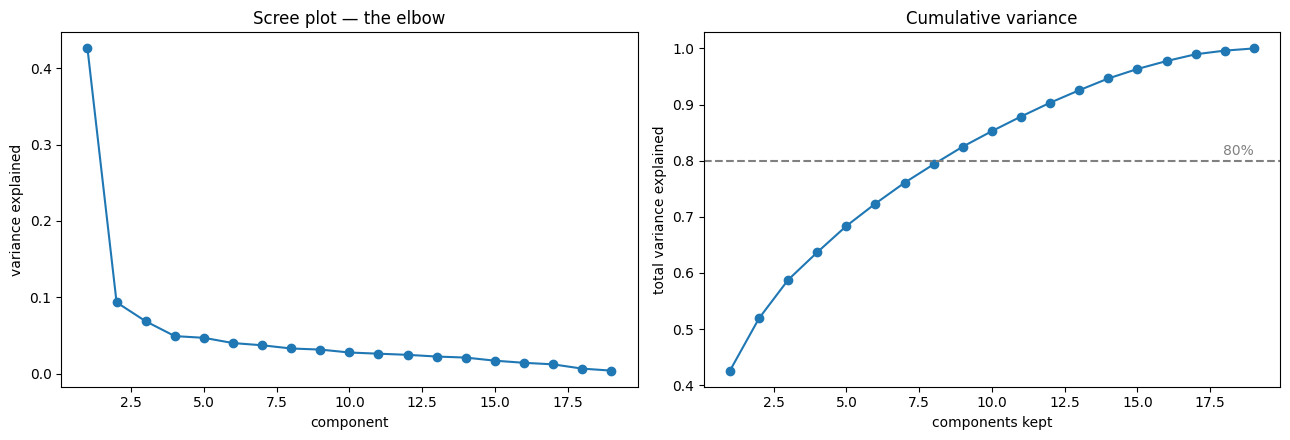

In [ ]:
components = range(1, len(variance) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(components, variance, marker='o')
ax1.set_title('Scree plot — the elbow')
ax1.set_xlabel('component'); ax1.set_ylabel('variance explained')

ax2.plot(components, cumulative, marker='o')
ax2.axhline(0.8, color='grey', linestyle='--')
ax2.text(len(variance), 0.81, '80%', ha='right', color='grey')
ax2.set_title('Cumulative variance')
ax2.set_xlabel('components kept'); ax2.set_ylabel('total variance explained')

plt.tight_layout()
plt.show()

### Exercise 1

Answer three questions from the table and the plots:

1. Where does the scree plot bend?
2. How many components have an **eigenvalue above 1**? (the Kaiser rule — a component
   worth keeping should explain more than a single original column does)
3. How many components do you need to reach **80%** cumulative variance?

Then decide how many you would keep, and why.

In [ ]:
# YOUR CODE HERE

In [ ]:
#@title Solution 1
print('components with eigenvalue above 1:', (pca_full.explained_variance_ > 1).sum())
print('components needed to reach 80%   :', (cumulative < 0.8).sum() + 1)

components with eigenvalue above 1: 3
components needed to reach 80%   : 9


**The two rules disagree, and that is the lesson.**

* The scree plot bends hard after **PC3** — PC1 alone carries 43%, and from PC4 onward
  each component adds about 4% and the curve is flat.
* The Kaiser rule also says **3** components have an eigenvalue above 1.
* But reaching 80% cumulative variance would need **9** components.

We keep **3**. Two rules out of three point there, and the components after PC3 are all
roughly the same size, which means they are noise rather than structure.

In [ ]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X)

print('keeping 3 components,', round(pca.explained_variance_ratio_.sum(), 3), 'of the variance')
print('shape:', X_pca.shape)

keeping 3 components, 0.588 of the variance
shape: (780, 3)


---
## 2. Now choose how many clusters

A different question, and a different elbow. The scree elbow above was about
**columns**; this one is about **groups**.

* **Inertia** — total distance from each city to its cluster centre. Always falls as k
  rises, so look for the bend.
* **Silhouette** — how well separated the groups are, from &minus;1 to 1. Higher is better.

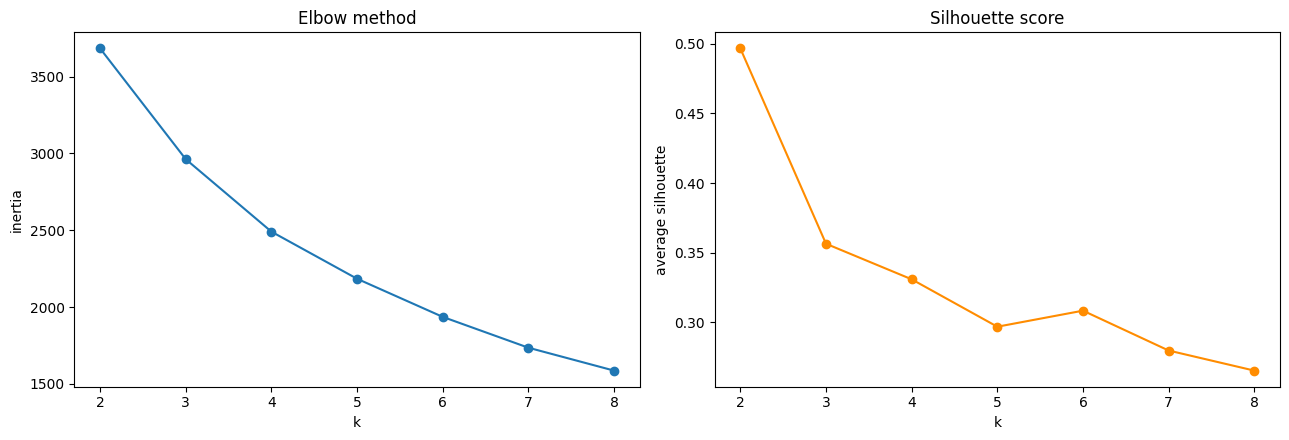

,k,inertia,silhouette
0,2,3683,0.496
1,3,2962,0.356
2,4,2491,0.331
3,5,2184,0.297
4,6,1936,0.308
5,7,1736,0.280
6,8,1587,0.265


In [ ]:
ks = range(2, 9)
inertia = []
silhouette = []

for k in ks:
    model = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_pca)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_pca, model.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(ks, inertia, marker='o')
ax1.set_title('Elbow method'); ax1.set_xlabel('k'); ax1.set_ylabel('inertia')
ax2.plot(ks, silhouette, marker='o', color='darkorange')
ax2.set_title('Silhouette score'); ax2.set_xlabel('k'); ax2.set_ylabel('average silhouette')
plt.tight_layout()
plt.show()

pd.DataFrame({'k': ks, 'inertia': [round(i) for i in inertia],
              'silhouette': [round(s, 3) for s in silhouette]})

### Exercise 2

The silhouette is highest at **k = 2**. Run K-means with k = 2 and look at the two
groups. Would you present that to a client?

Then run k = 4 and compare.

In [ ]:
# YOUR CODE HERE

In [ ]:
#@title Solution 2
# k = 2 scores best, but it only says "rich world" and "poor world" - nothing new.
# k = 4 splits each of those in two, giving four types you can act on differently.
labels = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(X_pca)

cities.assign(g=labels).groupby('g')[
    ['cost_nomad', 'internet_speed', 'safety', 'life_score']].mean().round(2)

,cost_nomad,internet_speed,safety,life_score
g,,,,
0,3019.01,21.40,0.80,0.81
1,1654.98,5.93,0.56,0.59


In [ ]:
cities['cluster_pca'] = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_pca)
cities['cluster_pca'].value_counts().sort_index()

cluster_pca
0    280
1    196
2     80
3    224
Name: count, dtype: int64

---
## 3. Naming the four types

Cluster numbers mean nothing — they change every time the code runs on a different
machine. Read the numbers, then give each group a name a person would use.

In [ ]:
profile = cities.groupby('cluster_pca')[
    ['cost_nomad', 'internet_speed', 'safety', 'freedom_score', 'nightlife', 'life_score']
].median().round(2)

profile['cities'] = cities['cluster_pca'].value_counts().sort_index()
profile.sort_values('cost_nomad')

,cost_nomad,internet_speed,safety,freedom_score,nightlife,life_score,cities
cluster_pca,,,,,,,
3,1372.5,3.0,0.60,0.2,0.4,0.59,224
1,1675.0,6.0,0.60,0.4,0.6,0.69,196
0,2860.0,18.0,0.80,0.6,0.6,0.82,280
2,3943.5,15.5,0.76,0.6,0.6,0.78,80


In [ ]:
# The cities closest to the middle of each group are the most typical members.
for c in sorted(cities['cluster_pca'].unique()):
    group = cities[cities['cluster_pca'] == c]
    examples = ', '.join(group.nlargest(4, 'life_score')['place'])
    print(f"cluster {c}: {len(group):3d} cities, "
          f"${group.cost_nomad.median():.0f}/month -> {examples}")

cluster 0: 280 cities, $2860/month -> Miami, Austin, Portland, Las Vegas
cluster 1: 196 cities, $1675/month -> Budapest, New Taipei City, Kaohsiung, Macau
cluster 2:  80 cities, $3944/month -> Philadelphia, Oakland, Key West, Geneva
cluster 3: 224 cities, $1372/month -> Kuala Lumpur, Ao Nang, Dorobo, Skopje


### Exercise 3

Fill in `TYPE_NAMES` with a name for each cluster number, then run the cell.

Use the table above. The four groups differ mainly on **cost** and on the
**safety / freedom / internet** block that moves together.

In [ ]:
TYPE_NAMES = {0: '...', 1: '...', 2: '...', 3: '...'}

cities['type'] = cities['cluster_pca'].map(TYPE_NAMES)
cities['type'].value_counts()

type
...    780
Name: count, dtype: int64

In [ ]:
#@title Solution 3
TYPE_NAMES = {
    3: 'Budget & building',     # $1,372 · 3 Mbps · safety 0.51
    1: 'Emerging value hubs',   # $1,675 · 6 Mbps · safety 0.64
    0: 'Established hubs',      # $2,860 · 18 Mbps · safety 0.85
    2: 'Premium-priced',        # $3,944 · 16 Mbps · safety 0.66 - costs most, scores less
}

cities['type'] = cities['cluster_pca'].map(TYPE_NAMES)
cities['type'].value_counts()

type
Established hubs       280
Budget & building      224
Emerging value hubs    196
Premium-priced          80
Name: count, dtype: int64

---
## 4. Three results worth presenting

A segmentation is only useful if it tells somebody something they did not know.

### Result 1 — value for money

Divide the life score by the monthly cost. Which type gives you the most per dollar?

In [ ]:
cities['value'] = cities['life_score'] / (cities['cost_nomad'] / 1000)

cities.groupby('type')['value'].median().round(3).sort_values(ascending=False)

type
Budget & building      0.415
Emerging value hubs    0.412
Established hubs       0.289
Premium-priced         0.193
Name: value, dtype: float64

**Emerging value hubs match the cheapest cities on value per dollar** — but with a life
score of 0.68 instead of 0.54 and safety of 0.64 instead of 0.51. Same efficiency,
noticeably better place. That is the sweet spot of this market.

### Result 2 — the premium trap

The most expensive group is *not* the best group.

In [ ]:
comparison = cities[cities['type'].isin(['Established hubs', 'Premium-priced'])]

comparison.groupby('type')[
    ['cost_nomad', 'internet_speed', 'safety', 'freedom_score', 'lgbt_friendly', 'life_score']
].mean().round(2)

,cost_nomad,internet_speed,safety,freedom_score,lgbt_friendly,life_score
type,,,,,,
Established hubs,2850.41,22.89,0.85,0.71,0.75,0.83
Premium-priced,4042.90,17.66,0.66,0.53,0.60,0.75


In [ ]:
premium = cities[cities['type'] == 'Premium-priced']
print('most expensive members:', ', '.join(premium.nlargest(6, 'cost_nomad')['place']))

most expensive members: Hamilton, Saint Helier, Lausanne, Anápolis, Jerusalem, Dubai


Premium-priced cities cost **38% more** than Established hubs and score **lower on every
single dimension** — slower internet, less safe, less free, lower life score. Look at who
they are: Monaco, Lausanne, Jersey, Bermuda, Dubai. These are **tax and finance hubs, not
nomad hubs**. You are paying for an address, not for working conditions.

For a relocation service this is a segment to warn people about, not sell to.

### Exercise 4 — the arbitrage list

Find the 10 **cheapest** cities that still ended up in `Established hubs`.
These are places with top-tier conditions at a budget-tier price.

Show `place`, `region`, `cost_nomad`, `internet_speed`, `safety` and `life_score`.

In [ ]:
# YOUR CODE HERE

In [ ]:
#@title Solution 4
established = cities[cities['type'] == 'Established hubs']

established.nsmallest(10, 'cost_nomad')[
    ['place', 'region', 'cost_nomad', 'internet_speed', 'safety', 'life_score']
]

,place,region,cost_nomad,internet_speed,safety,life_score
84,Battle Creek,Americas,1310.0,34.0,0.6,0.78
148,Braga,Europe,1322.0,29.0,0.8,0.83
252,Gwangju,Asia,1486.0,27.0,1.0,0.82
16,Taipei,Asia,1545.0,16.0,1.0,0.93
14,Prague,Europe,1639.0,15.0,0.8,0.83
146,Porto,Europe,1681.0,21.0,0.8,0.84
627,Kaunas,Europe,1681.0,32.0,0.6,0.72
248,Daegu,Asia,1708.0,30.0,1.0,0.87
249,Busan,Asia,1716.0,31.0,1.0,0.87
251,Daejeon,Asia,1725.0,37.0,1.0,0.82


**Taipei** is the standout: $1,545 a month with a perfect safety score and the highest
life score in the table. And notice **four South Korean cities** — Gwangju, Daegu, Busan,
Daejeon — all around $1,500–1,700 with 27–37 Mbps and perfect safety.

Nobody was looking at Daejeon. That is what clustering is for.

### Exercise 5 — does geography explain the types?

We never gave the algorithm `region`. Check whether it rediscovered it anyway:

1. cross-tabulate `type` against `region`
2. compute `adjusted_rand_score` between `type` and `region`

Before you run it, predict: high or low? What would each answer mean?

In [ ]:
# YOUR CODE HERE

In [ ]:
#@title Solution 5
print('agreement between type and continent:',
      round(adjusted_rand_score(cities['region'], cities['cluster_pca']), 3))

pd.crosstab(cities['type'], cities['region'])

agreement between type and continent: 0.155


region,Africa,Americas,Asia,Europe,Oceania
type,,,,,
Budget & building,26,21,153,23,1
Emerging value hubs,14,53,75,54,0
Established hubs,2,109,21,135,13
Premium-priced,3,38,13,23,3


**Low — about 0.16.** The types are not continents in disguise.

`Emerging value hubs` contains Budapest, Kaohsiung, Córdoba and Cape Town: four
continents, one city type. So *"cheap Asian cities"* is not a market segment, but
*"emerging value hub"* is — and it has members nearly everywhere.

One honest exception: **Budget & building is 153 of 224 Asian**. The cheap-and-
underdeveloped type really is geographically concentrated. The cross-continental claim
holds for the two middle types, which are the ones a business would actually target.

---
## 5. The picture

We clustered in PCA space, so we can plot the result in exactly that space.

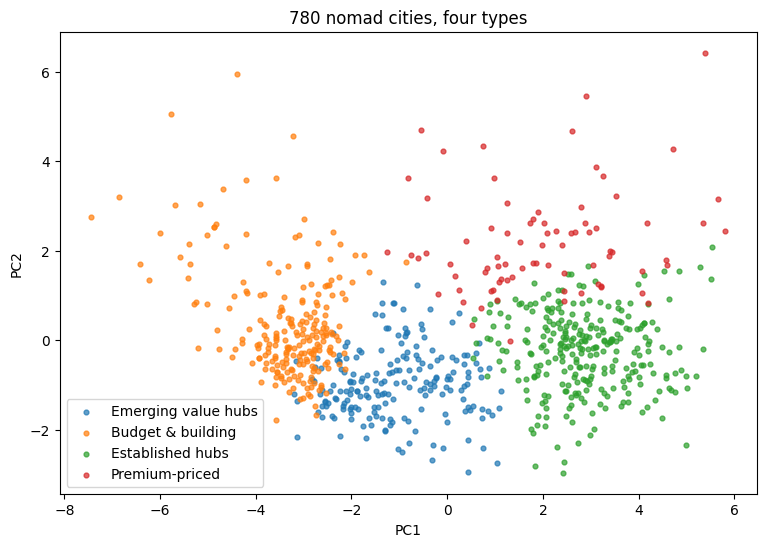

In [ ]:
plt.figure(figsize=(9, 6))

for name in cities['type'].unique():
    rows = X_pca[cities['type'] == name]
    plt.scatter(rows[:, 0], rows[:, 1], s=12, alpha=0.7, label=name)

plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('780 nomad cities, four types')
plt.legend()
plt.show()

---
## 6. One last check: hierarchical clustering

K-means made us choose k before it would say anything. **Hierarchical clustering**
does the opposite — it merges the two closest cities, then the two closest groups, and
keeps going until everything is one group. You read the number of clusters off the tree
afterwards.

If it finds the same four types, that is real reassurance: two different algorithms,
one answer.

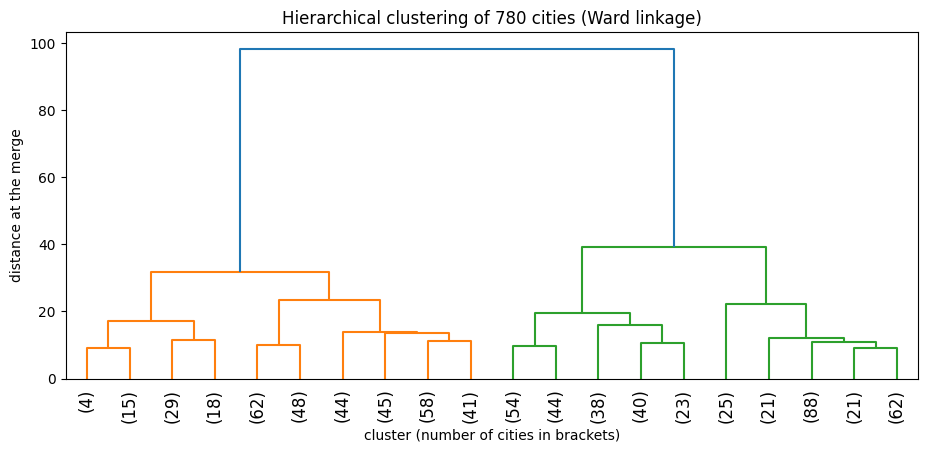

In [ ]:
linkage_matrix = linkage(X_pca, method='ward')

plt.figure(figsize=(11, 4.5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.title('Hierarchical clustering of 780 cities (Ward linkage)')
plt.xlabel('cluster (number of cities in brackets)')
plt.ylabel('distance at the merge')
plt.show()

The tree is truncated to its last 20 merges — 780 labels would be unreadable. Height is
how different two groups were when they merged, so the tall branches near the top are the
big, meaningful splits. Cutting just below the tallest join gives a handful of groups.

Let us cut it at four and see what we get.

In [ ]:
cities['hc'] = AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(X_pca)

cities.groupby('hc')[['cost_nomad', 'internet_speed', 'safety', 'life_score']].mean().round(2)

,cost_nomad,internet_speed,safety,life_score
hc,,,,
0,2864.49,22.55,0.83,0.82
1,1617.89,4.82,0.52,0.54
2,1696.54,8.42,0.63,0.68
3,4188.70,17.73,0.68,0.76


The same four levels: a budget group around $1,600, a mid group around $1,700 with better
scores, an established group around $2,900, and a small expensive group above $4,000.

Now check it properly rather than by eye.

In [ ]:
print('agreement with k-means:', round(adjusted_rand_score(cities['cluster_pca'], cities['hc']), 3))

pd.crosstab(cities['cluster_pca'], cities['hc'], rownames=['k-means'], colnames=['hierarchical'])

agreement with k-means: 0.837


hierarchical,0,1,2,3
k-means,,,,
0,273,0,1,6
1,5,7,183,1
2,20,0,1,59
3,0,210,14,0


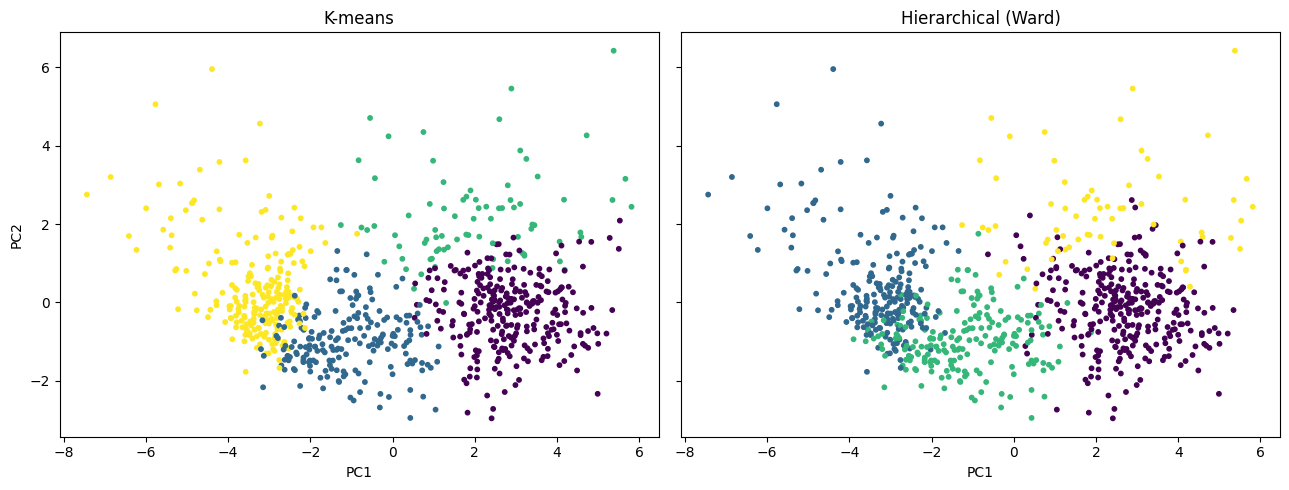

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for ax, labels, title in zip(axes, [cities['cluster_pca'], cities['hc']],
                             ['K-means', 'Hierarchical (Ward)']):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=10)
    ax.set_title(title)
    ax.set_xlabel('PC1')

axes[0].set_ylabel('PC2')
plt.tight_layout()
plt.show()

**Agreement is 0.84** — high. The two pictures look almost identical, and the
disagreements sit on the boundaries between groups, which is exactly where you would
expect two algorithms to differ.

The colours will not match between the two panels, because cluster numbers are arbitrary.
Look at the shapes, not the colours.

> **So the four types are not an artefact of K-means.** Two different algorithms, run on
> the same three components, found the same structure. That is the strongest evidence
> in this notebook that the segmentation is real.

---
## Wrap-up

1. **Scale before you cluster.** Dollars and megabits are not comparable numbers.
2. **Two size choices, two different elbows.** The scree plot chooses *columns*; the
   inertia plot chooses *groups*. Do not confuse them.
3. **Rules of thumb disagree, so decide and say why.** The elbow and Kaiser rule said 3
   components; the 80% rule said 9. We tested it, and it made no difference.
4. **The metric suggests, the business decides.** The silhouette preferred k = 2; we took
   k = 4 because two groups told us nothing we did not already know.
5. **Check with a second algorithm.** Hierarchical clustering found the same four types
   (agreement 0.84), which is better evidence than any single score.
6. **A type you cannot name is a type you cannot act on.**

**Take it further**

* Re-run with `n_clusters=3` and with `n_clusters=5`. Do the four names survive?
* Try clustering the 19 scaled columns directly, with no PCA at all. How much does the
  answer change? (Careful: to compare fairly, measure both silhouettes on the *same*
  data — a score computed in 3-D is not comparable with one computed in 19-D.)
* The premium group is defined by cost, not quality. What would you *tell* someone
  considering one of those cities?
* Try `AgglomerativeClustering` instead of `KMeans`. Same four types?